# Session 5 — Optimization and Materials Discovery: Bayesian Optimization & Active Learning

**Practical AI & Machine Learning for Materials Science · ACerS short course**

Prediction is nice, but the real payoff of ML in the lab is deciding **what to make next**.

In this notebook you will:
1. Fit a **Gaussian process** (GP) surrogate and read its uncertainty.
2. Write **acquisition functions** (Expected Improvement, Upper Confidence Bound) from scratch.
3. Run a **build → suggest → update** loop on a simulated sintering experiment.
4. Explore the **exploration vs. exploitation** trade-off.
5. Benchmark BO against random search on **real** flow-synthesis experiments (silver nanoparticles).

> **Key concept:** every experiment either *exploits* what you know or *explores* what you don't. BO makes that trade-off explicit and quantitative.

**Optional pre-watch:** "Gaussian Process" and "Bayesian Optimization" lectures on the
[course YouTube playlist](https://youtube.com/playlist?list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0).
Slides: [31. Gaussian Process](https://github.com/sp8rks/MaterialsInformatics/blob/main/course_notes/31.%20Gaussian%20Process.pdf),
[32. Bayesian Optimization](https://github.com/sp8rks/MaterialsInformatics/blob/main/course_notes/32.%20Bayesian%20Optimization.pdf).

## 0. Setup

In [1]:
# --- Setup: works locally and in Google Colab ---------------------------------
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/sp8rks/ACerS_AI_ML_Workshop"
if "google.colab" in sys.modules:
    ROOT = Path("/content/ACerS_AI_ML_Workshop")
    if not ROOT.exists():
        subprocess.run(["git", "clone", "-q", REPO_URL, str(ROOT)], check=True)
else:
    ROOT = Path.cwd().resolve()
    while not (ROOT / "workshop_utils").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("Workshop root:", ROOT)

Workshop root: C:\ACERS_AI_ML


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

from workshop_utils import load_dataset

warnings.filterwarnings("ignore", category=ConvergenceWarning)
plt.rcParams["figure.dpi"] = 110

## Part A — A simulated sintering campaign

Imagine optimizing the **sintering temperature** of a ceramic to maximize relative density. Each furnace run takes a day, so we can afford ~10 runs.
The "true" response below is hidden from the optimizer. It has a decent local optimum and a better, narrower global one.

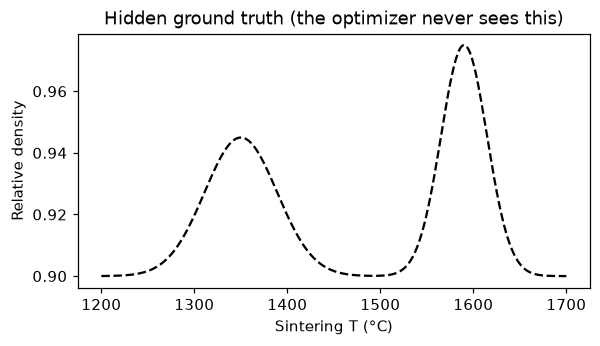

In [3]:
T_MIN, T_MAX = 1200, 1700  # °C
NOISE = 0.004

def true_density(T):
    return (0.90 + 0.045 * np.exp(-((T - 1350) / 55) ** 2)
                 + 0.075 * np.exp(-((T - 1590) / 35) ** 2))

def run_furnace(T, rng):
    """One noisy 'experiment'."""
    return true_density(T) + rng.normal(0, NOISE)

T_grid = np.linspace(T_MIN, T_MAX, 501)
plt.figure(figsize=(6, 3))
plt.plot(T_grid, true_density(T_grid), "k--")
plt.xlabel("Sintering T (°C)"); plt.ylabel("Relative density")
plt.title("Hidden ground truth (the optimizer never sees this)")
plt.show()

### A1. The surrogate: a Gaussian process

A GP gives a **mean prediction** μ(x) and an **uncertainty** σ(x) everywhere. Uncertainty is small near data and grows away from it.

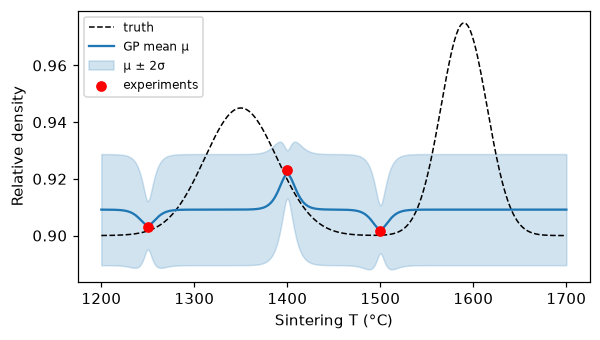

In [4]:
def to_unit(T):
    return ((np.asarray(T, dtype=float) - T_MIN) / (T_MAX - T_MIN)).reshape(-1, 1)

def fit_gp(X, y):
    kernel = (ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale=0.2, length_scale_bounds=(0.02, 2), nu=2.5)
              + WhiteKernel(1e-4, (1e-8, 1e-1)))
    return GaussianProcessRegressor(kernel, normalize_y=True, n_restarts_optimizer=3, random_state=0).fit(X, y)

rng = np.random.default_rng(1)
T_obs = np.array([1250, 1400, 1500])
y_obs = np.array([run_furnace(t, rng) for t in T_obs])

gp = fit_gp(to_unit(T_obs), y_obs)
mu, sd = gp.predict(to_unit(T_grid), return_std=True)

plt.figure(figsize=(6, 3.2))
plt.plot(T_grid, true_density(T_grid), "k--", lw=1, label="truth")
plt.plot(T_grid, mu, "C0", label="GP mean μ")
plt.fill_between(T_grid, mu - 2 * sd, mu + 2 * sd, color="C0", alpha=0.2, label="μ ± 2σ")
plt.scatter(T_obs, y_obs, c="red", zorder=3, label="experiments")
plt.xlabel("Sintering T (°C)"); plt.ylabel("Relative density"); plt.legend(fontsize=8)
plt.show()

### A2. Acquisition functions: turning μ and σ into a decision

- **Upper Confidence Bound:** $\text{UCB}(x) = \mu(x) + \kappa\,\sigma(x)$. Large κ means more exploration.
- **Expected Improvement:** how much we *expect* to beat the current best $y^*$:
$$\text{EI}(x) = (\mu - y^* - \xi)\,\Phi(z) + \sigma\,\phi(z), \quad z = \frac{\mu - y^* - \xi}{\sigma}$$
  The first term rewards a high mean (exploitation). The second rewards high uncertainty (exploration).

In [5]:
def expected_improvement(mu, sd, best, xi=0.0):
    sd = np.maximum(sd, 1e-12)
    z = (mu - best - xi) / sd
    return (mu - best - xi) * norm.cdf(z) + sd * norm.pdf(z)

def ucb(mu, sd, kappa=2.0):
    return mu + kappa * sd

### A3. The loop: build → suggest → update

In [6]:
def bo_loop(n_iter=8, acq="EI", xi=0.0, kappa=2.0, seed=1, T_init=(1250, 1400, 1500), plot=True):
    rng = np.random.default_rng(seed)
    T_obs = list(T_init)
    y_obs = [run_furnace(t, rng) for t in T_obs]
    if plot:
        fig, axes = plt.subplots(n_iter, 1, figsize=(7, 1.9 * n_iter), sharex=True)
    for i in range(n_iter):
        gp = fit_gp(to_unit(T_obs), np.array(y_obs))                       # BUILD
        mu, sd = gp.predict(to_unit(T_grid), return_std=True)
        a = expected_improvement(mu, sd, max(y_obs), xi) if acq == "EI" else ucb(mu, sd, kappa)
        T_next = T_grid[np.argmax(a)]                                       # SUGGEST
        if plot:
            ax = axes[i]
            ax.plot(T_grid, true_density(T_grid), "k--", lw=0.8)
            ax.plot(T_grid, mu, "C0"); ax.fill_between(T_grid, mu - 2 * sd, mu + 2 * sd, alpha=0.2)
            ax.scatter(T_obs, y_obs, c="red", s=15, zorder=3)
            ax2 = ax.twinx(); ax2.fill_between(T_grid, 0, a, color="C2", alpha=0.3); ax2.set_yticks([])
            ax.axvline(T_next, color="C2", ls=":")
            ax.set_ylabel(f"iter {i + 1}", fontsize=8)
        T_obs.append(T_next); y_obs.append(run_furnace(T_next, rng))        # UPDATE (run experiment)
    if plot:
        axes[-1].set_xlabel("Sintering T (°C)   [green = acquisition, dotted = next experiment]")
        plt.tight_layout(); plt.show()
    return np.array(T_obs), np.array(y_obs)

def report(T_hist, label):
    i = np.argmax(true_density(T_hist))
    print(f"{label}: best run at {T_hist[i]:.0f} °C → true density {true_density(T_hist[i]):.4f}   "
          f"(global optimum {true_density(T_grid).max():.4f} at {T_grid[np.argmax(true_density(T_grid))]:.0f} °C)")
    print("   experiments chosen:", [int(t) for t in T_hist[3:]])

# First: pure greedy Expected Improvement (xi = 0)
T_greedy, _ = bo_loop(n_iter=8, acq="EI", xi=0.0, plot=False)
report(T_greedy, "EI, xi=0   ")

EI, xi=0   : best run at 1347 °C → true density 0.9449   (global optimum 0.9750 at 1590 °C)
   experiments chosen: [1396, 1405, 1425, 1402, 1361, 1345, 1347, 1347]


Greedy EI found the first decent peak near 1350 °C and kept refining it. **It never looked at 1550–1650 °C**, where the better optimum is. Its GP was confident (wrongly) that nothing better was out there.

Now add a small **exploration bonus** ξ = 0.02: a point only counts as an improvement if it beats the current best by a margin.

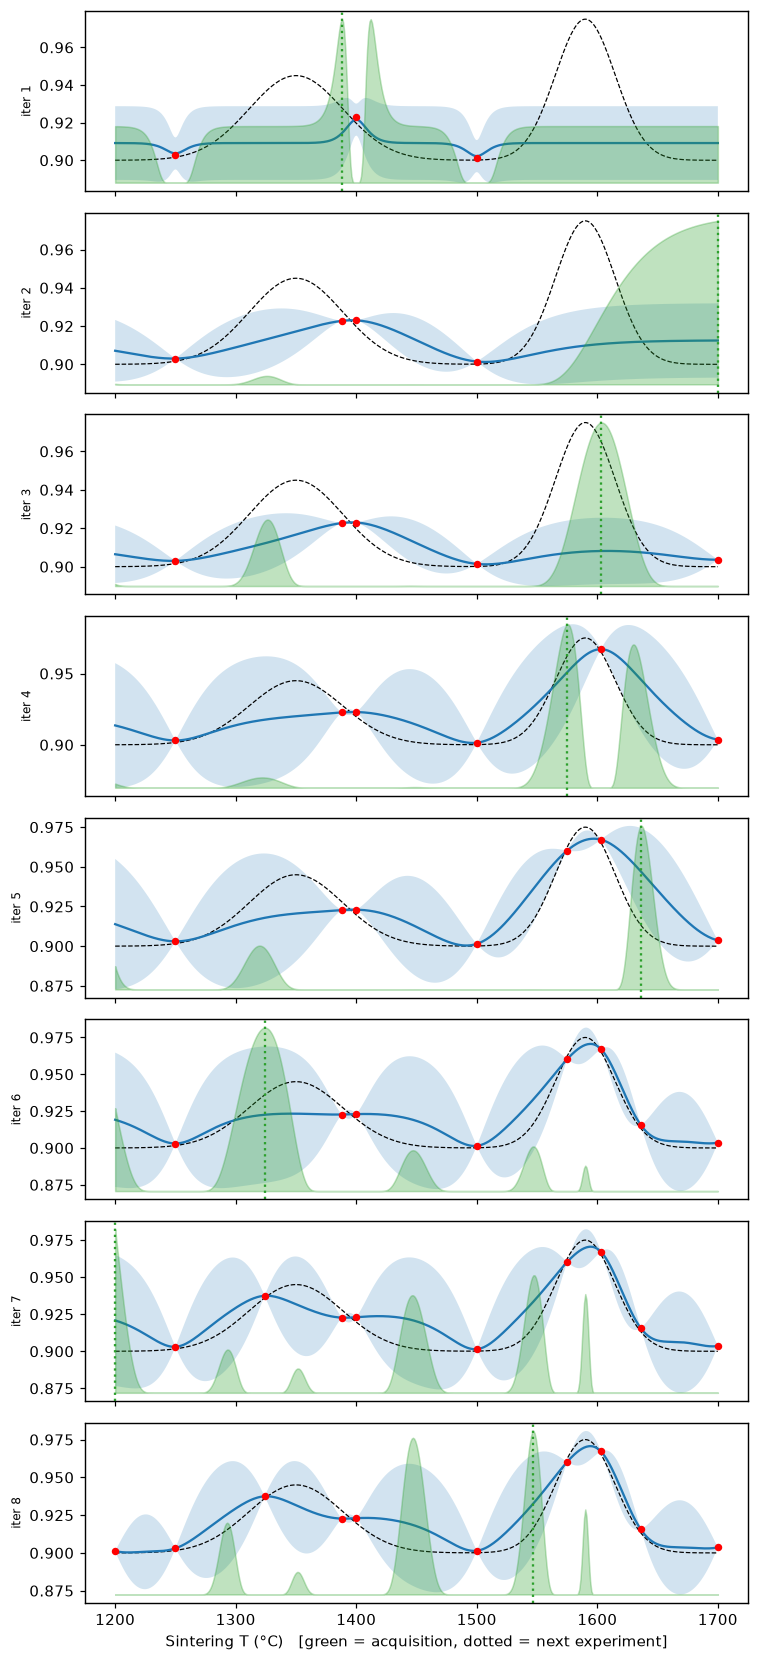

EI, xi=0.02: best run at 1603 °C → true density 0.9653   (global optimum 0.9750 at 1590 °C)
   experiments chosen: [1388, 1700, 1603, 1575, 1636, 1324, 1200, 1547]


In [7]:
T_hist, y_hist = bo_loop(n_iter=8, acq="EI", xi=0.02)
report(T_hist, "EI, xi=0.02")

Watch the acquisition (green) jump to the unexplored high-temperature edge, discover the second peak, and then refine it, while occasionally checking other gaps.

### A4. Exploration vs. exploitation

Run many campaigns (different noise and random starts) with three settings of UCB's κ, and track the **best density found so far**.

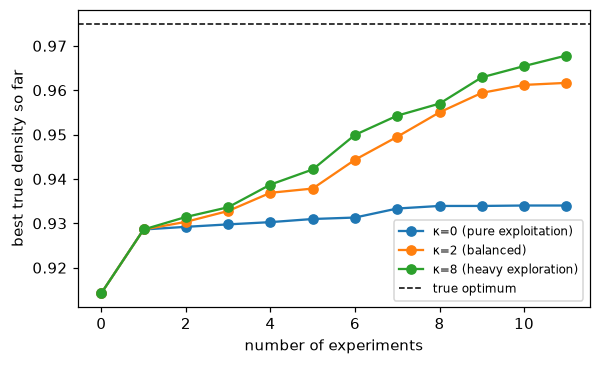

In [8]:
def campaign_best(kappa, seed, n_iter=10):
    rng = np.random.default_rng(seed)
    T_init = rng.uniform(T_MIN, T_MAX, 2)
    T, y = bo_loop(n_iter=n_iter, acq="UCB", kappa=kappa, seed=seed, T_init=T_init, plot=False)
    return np.maximum.accumulate(true_density(T))   # judge by the noise-free truth

fig, ax = plt.subplots(figsize=(6, 3.5))
for kappa, label in [(0.0, "κ=0 (pure exploitation)"), (2.0, "κ=2 (balanced)"), (8.0, "κ=8 (heavy exploration)")]:
    curves = np.array([campaign_best(kappa, s) for s in range(12)])
    ax.plot(curves.mean(0), "o-", label=label)
ax.axhline(true_density(T_grid).max(), color="k", ls="--", lw=1, label="true optimum")
ax.set_xlabel("number of experiments"); ax.set_ylabel("best true density so far")
ax.legend(fontsize=8)
plt.show()

**Discussion:** Pure exploitation often gets stuck on the first decent peak (1350 °C). Heavy exploration wastes runs mapping uninteresting regions. In real experiments, how much to explore also depends on your **budget** and on the cost of a failed run.

## Part B — Real experiments: silver nanoparticle flow synthesis

This dataset comes from a high-throughput microfluidic synthesis of silver nanoparticles
([Mekki-Berrada *et al.*, npj Comput. Mater. 2021](https://www.semanticscholar.org/paper/915e7d410e2a11c17dcfd911bfed14e4a03b675f)),
later used as a BO benchmark ([Liang *et al.*, npj Comput. Mater. 2021](https://www.semanticscholar.org/paper/b52d120b7a105f31590efc403e9afcdcfb397f1e)).

- **Inputs (5):** flow-rate ratios of AgNO₃, PVA, trisodium citrate and seed solutions, plus total flow rate
- **Objective:** `loss`, the mismatch between the measured and target optical spectrum. **Lower is better.**

We treat the **measured conditions as a menu** of allowed experiments (pool-based BO). The optimizer can only "run" a recipe by revealing its measured loss. No simulator is needed: these are real outcomes.

In [9]:
agnp = load_dataset("agnp")
inputs = ["QAgNO3(%)", "Qpva(%)", "Qtsc(%)", "Qseed(%)", "Qtot(uL/min)"]
pool = agnp.groupby(inputs, as_index=False)["loss"].mean()   # average replicate measurements
print(f"{len(agnp)} measurements → {len(pool)} unique recipes")
pool.describe().round(2)

3295 measurements → 164 unique recipes


,QAgNO3(%),Qpva(%),Qtsc(%),Qseed(%),Qtot(uL/min),loss
count,164.00,164.00,164.00,164.00,164.00,164.00
mean,23.18,24.33,8.84,6.96,705.84,0.51
std,8.65,8.66,7.39,4.53,211.58,0.20
min,4.53,10.00,0.50,0.50,200.00,0.15
25%,17.79,17.79,4.00,4.00,600.00,0.35
50%,22.01,22.60,5.86,6.50,807.56,0.50
75%,30.50,31.50,12.76,8.73,815.28,0.67
max,42.81,40.00,30.50,19.50,983.00,0.91


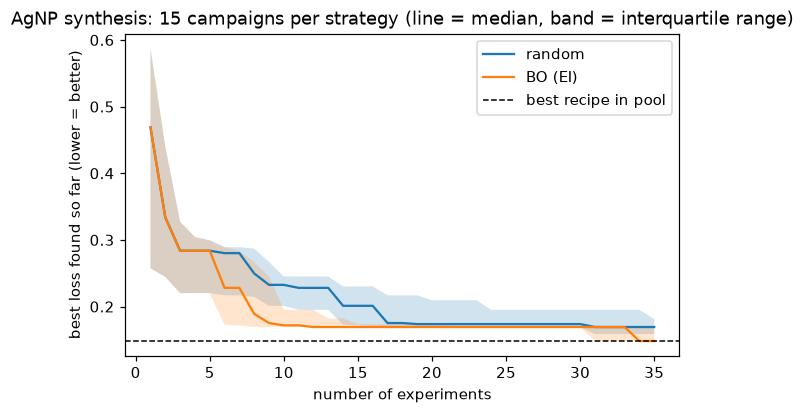

random  : median experiments to reach a top-5% recipe = 9 (succeeded in 13/15 campaigns)
BO (EI) : median experiments to reach a top-5% recipe = 6 (succeeded in 15/15 campaigns)


In [10]:
Xp = pool[inputs].to_numpy()
Xp = (Xp - Xp.min(0)) / (Xp.max(0) - Xp.min(0))      # scale to [0, 1]
yp = pool["loss"].to_numpy()
best_possible = yp.min()

def fit_gp_nd(X, y):
    kernel = (ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale=np.ones(X.shape[1]) * 0.3,
                                                       length_scale_bounds=(0.03, 10), nu=2.5)
              + WhiteKernel(1e-3, (1e-6, 1e-1)))
    return GaussianProcessRegressor(kernel, normalize_y=True, n_restarts_optimizer=1, random_state=0).fit(X, y)

def run_campaign(strategy, seed, n_init=5, budget=35):
    rng = np.random.default_rng(seed)
    tried = list(rng.choice(len(yp), n_init, replace=False))
    while len(tried) < budget:
        untried = np.setdiff1d(np.arange(len(yp)), tried)
        if strategy == "random":
            nxt = rng.choice(untried)
        else:
            gp = fit_gp_nd(Xp[tried], yp[tried])
            mu, sd = gp.predict(Xp[untried], return_std=True)
            # we MINIMIZE loss → maximize EI of the negated objective
            nxt = untried[np.argmax(expected_improvement(-mu, sd, -yp[tried].min(), xi=0.01))]
        tried.append(nxt)
    return np.minimum.accumulate(yp[tried])

n_seeds = 15
res = {s: np.array([run_campaign(s, seed) for seed in range(n_seeds)]) for s in ["random", "BO (EI)"]}

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for name, curves in res.items():
    m, lo, hi = np.median(curves, 0), np.percentile(curves, 25, 0), np.percentile(curves, 75, 0)
    x = np.arange(1, len(m) + 1)
    ax.plot(x, m, label=name); ax.fill_between(x, lo, hi, alpha=0.2)
ax.axhline(best_possible, color="k", ls="--", lw=1, label="best recipe in pool")
ax.set_xlabel("number of experiments"); ax.set_ylabel("best loss found so far (lower = better)")
ax.set_title(f"AgNP synthesis: {n_seeds} campaigns per strategy (line = median, band = interquartile range)")
ax.legend()
plt.show()

for name, curves in res.items():
    hits = (curves <= np.percentile(yp, 5)).argmax(1) + 1
    hits = np.where((curves <= np.percentile(yp, 5)).any(1), hits, np.nan)
    print(f"{name:8s}: median experiments to reach a top-5% recipe = {np.nanmedian(hits):.0f} "
          f"(succeeded in {np.isfinite(hits).sum()}/{n_seeds} campaigns)")

**This is how ML accelerates discovery:** not by predicting perfectly, but by needing fewer experiments to reach a good result.

## Part C — Active learning vs. Bayesian optimization

| | Goal | Picks the next point with… |
|---|---|---|
| **Bayesian optimization** | find the *best* material/process | high EI / UCB (good **and** uncertain) |
| **Active learning** | build the most *accurate model* for the fewest labels | highest uncertainty σ |

Same machinery, different objective. Below, active learning picks the *most uncertain* recipes, and we track how well the GP predicts the whole pool.

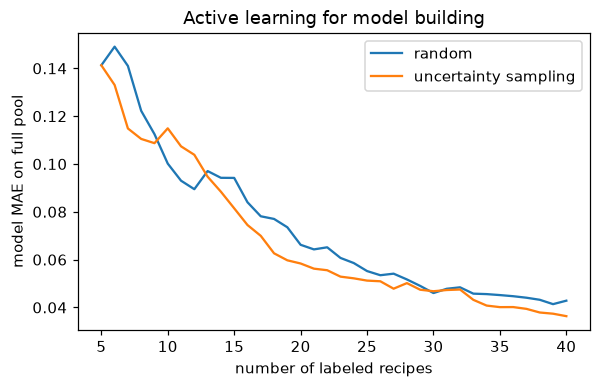

In [11]:
from sklearn.metrics import mean_absolute_error

def al_campaign(strategy, seed, n_init=5, budget=40):
    rng = np.random.default_rng(seed)
    tried = list(rng.choice(len(yp), n_init, replace=False))
    errs = []
    while len(tried) <= budget:
        gp = fit_gp_nd(Xp[tried], yp[tried])
        errs.append(mean_absolute_error(yp, gp.predict(Xp)))
        untried = np.setdiff1d(np.arange(len(yp)), tried)
        if strategy == "random":
            tried.append(rng.choice(untried))
        else:
            _, sd = gp.predict(Xp[untried], return_std=True)
            tried.append(untried[np.argmax(sd)])
    return np.array(errs)

fig, ax = plt.subplots(figsize=(6, 3.5))
for s in ["random", "uncertainty sampling"]:
    e = np.array([al_campaign(s, seed) for seed in range(6)])
    ax.plot(np.arange(5, 5 + e.shape[1]), e.mean(0), label=s)
ax.set_xlabel("number of labeled recipes"); ax.set_ylabel("model MAE on full pool")
ax.legend(); ax.set_title("Active learning for model building")
plt.show()

## Practical advice for real campaigns
- **Start with a space-filling design** (Latin hypercube / Sobol) of ~5–10 runs before BO.
- **Batch** suggestions when you can run several samples per furnace load (q-EI, Kriging believer).
- **Constraints and multiple objectives** (density *and* grain size, cost) are routine. See [BoTorch](https://botorch.org/) / [Ax](https://ax.dev/).
- Use [**Honegumi**](https://honegumi.readthedocs.io/) to generate a ready-to-run Ax script for your exact problem setup.
- Keep a human in the loop: reject suggestions that are unsafe or physically silly, and **log everything** (including failures).

## Hands-on exercises
1. In Part A, switch to `acq="UCB"` with `kappa=0.5` and `kappa=5`. How do the paths differ?
2. Change the initial experiments to `T_init=(1300, 1350, 1380)` (all near the local peak). Which `xi` values let EI escape? Is there a downside to a large `xi`?
3. In Part B, give BO a smaller budget (15 experiments). Is it still worth it vs. random?
4. **Your process:** write down 2–5 input variables, their ranges, and an objective for a process you run. Paste it into [Honegumi](https://honegumi.readthedocs.io/) to get starter code.

---
**Next session:** LLMs and agents: extracting data from text, retrieval-augmented generation, and an end-to-end AI workflow.

**Go deeper:** full course `worked_examples/bayesian_optimization` (deep-dive notebook, Ax and Honegumi workflows), `worked_examples/Bayesian_Optimization_livecoding`, `worked_examples/gaussian_process` ·
[A Visual Exploration of Gaussian Processes](https://distill.pub/2019/visual-exploration-gaussian-processes/).